In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
df=pd.read_csv("/workspaces/Aress_Task/data/Housing.csv")

In [142]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [144]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [147]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

*EDA*

In [148]:
# numeric summaries and distributions
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(df[num_cols].columns)
print(df[num_cols].describe())

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


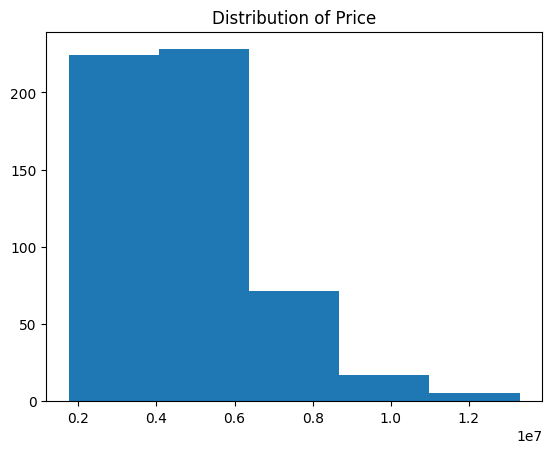

In [149]:
x=df["price"]
plt.hist(x,bins=5)
plt.title("Distribution of Price")
plt.show()


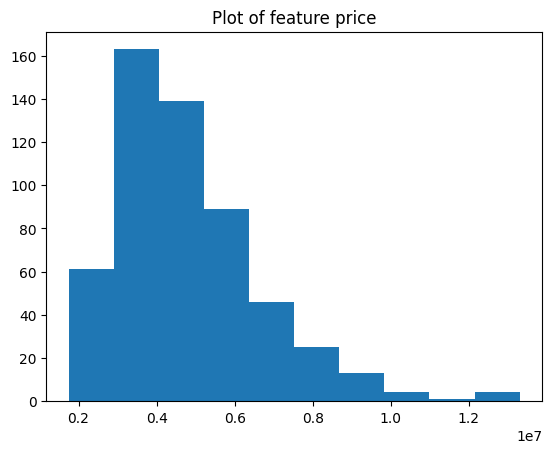

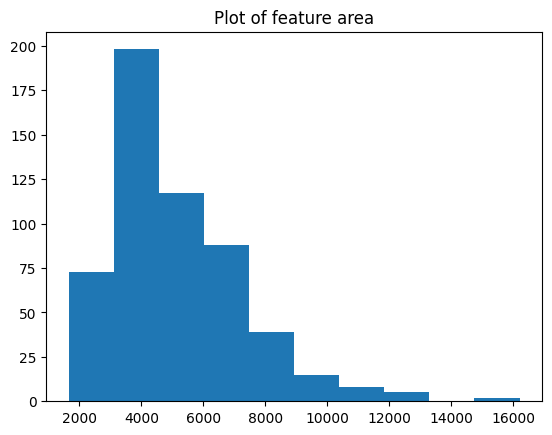

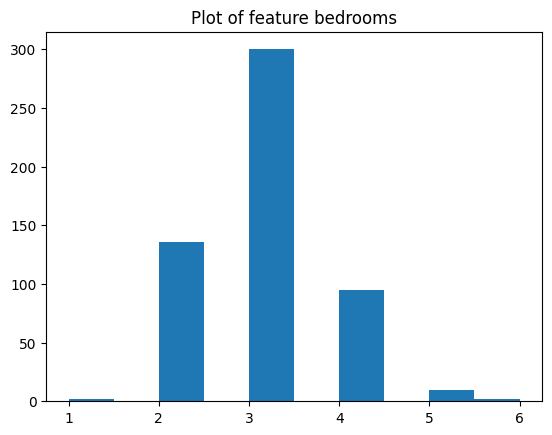

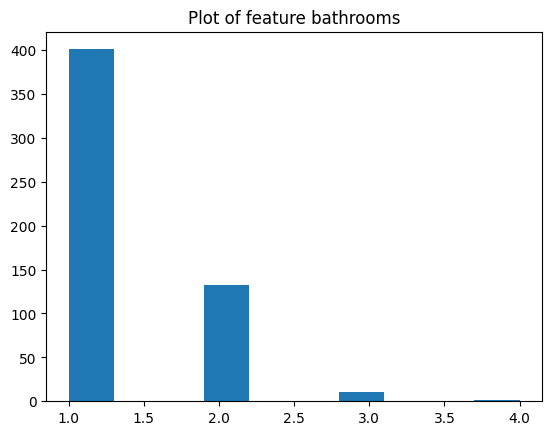

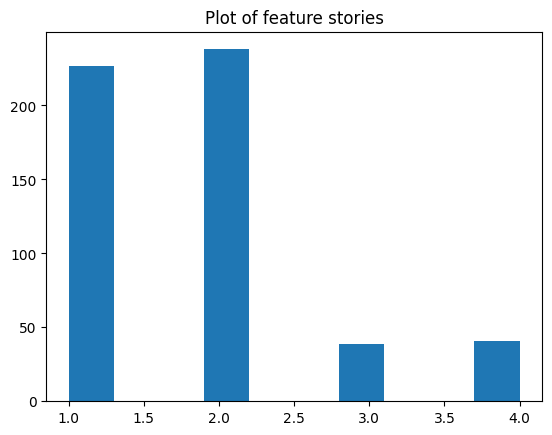

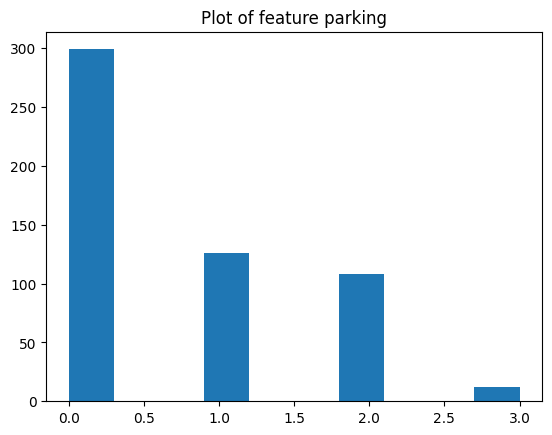

In [150]:
## Histogram for the data distribution.
for col in num_cols:
    plt.hist(df[col])
    plt.title(f'Plot of feature {col}')
    plt.show()

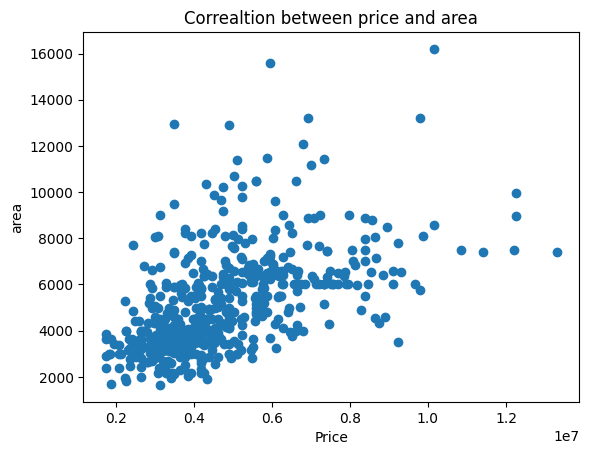

In [151]:
## Price and area relation

plt.scatter(x=df['price'],y=df['area'])
plt.title("Correaltion between price and area")
plt.xlabel("Price")
plt.ylabel("area")
plt.show()

In [152]:
## Applying log on screwed data
skewed_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking','price']

for col in skewed_features:
    df[col] = np.log1p(df[col])  


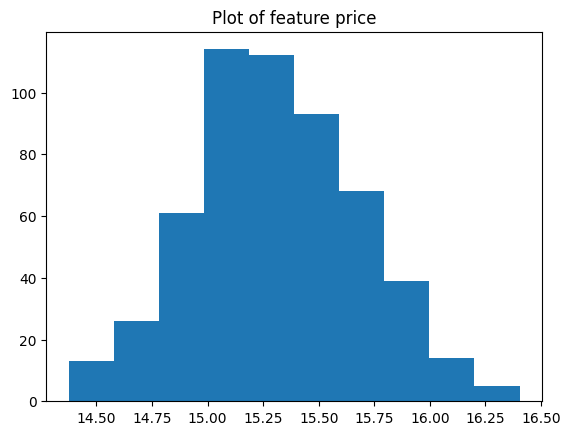

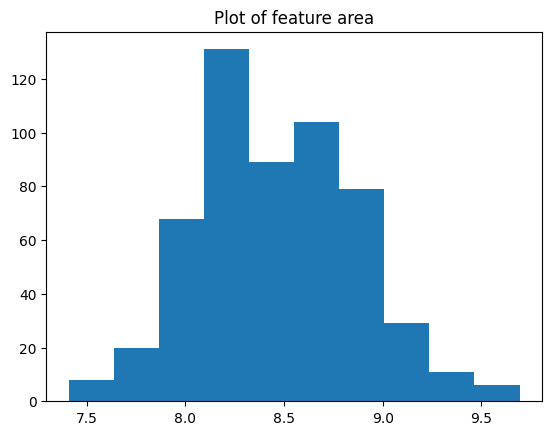

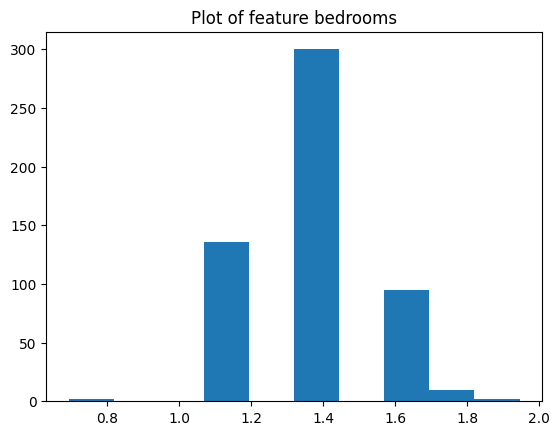

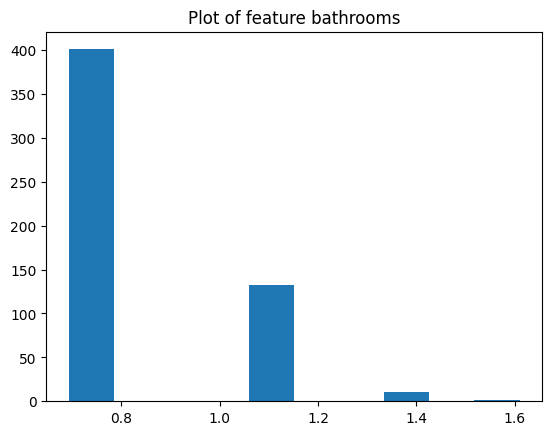

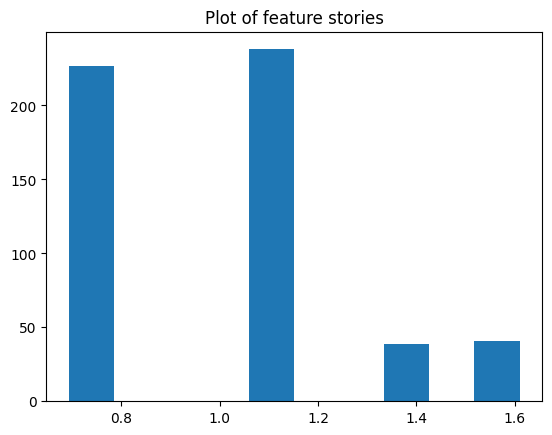

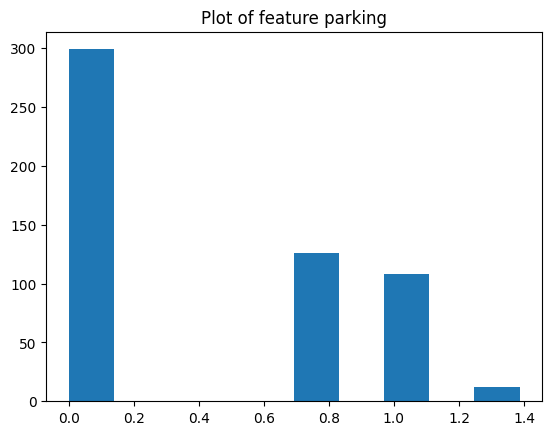

In [153]:
## Histogram for the data distribution after log transformation.
for col in num_cols:
    plt.hist(df[col])
    plt.title(f'Plot of feature {col}')
    plt.show()

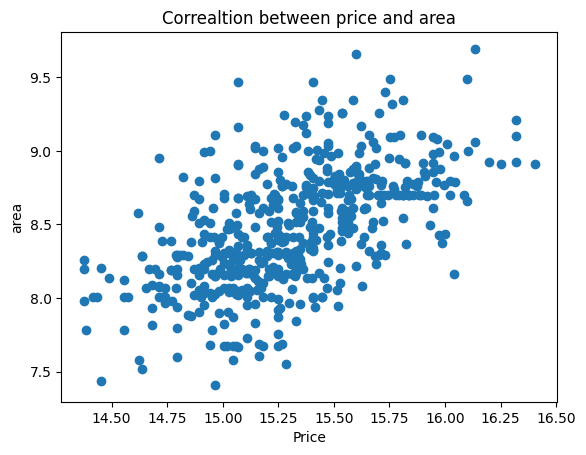

In [154]:
## Price and area relation after log transformation

plt.scatter(x=df['price'],y=df['area'])
plt.title("Correaltion between price and area")
plt.xlabel("Price")
plt.ylabel("area")
plt.show()

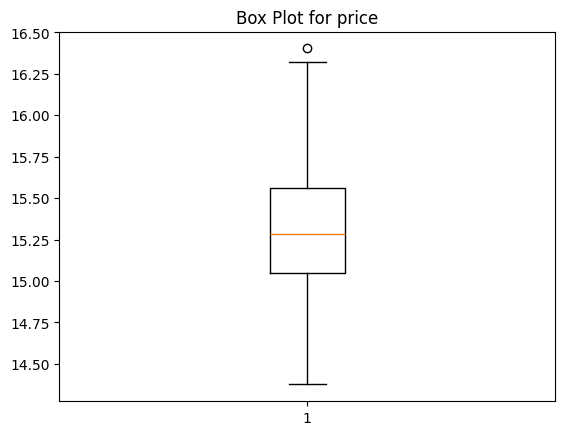

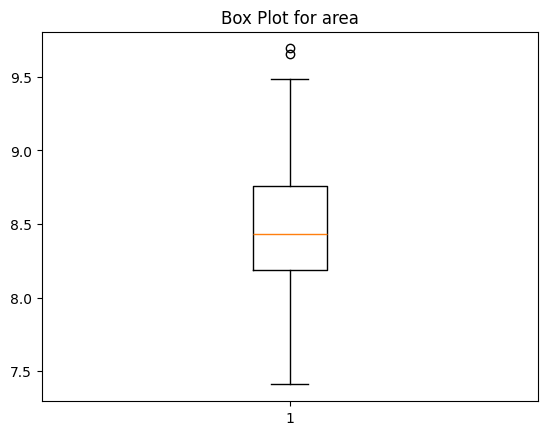

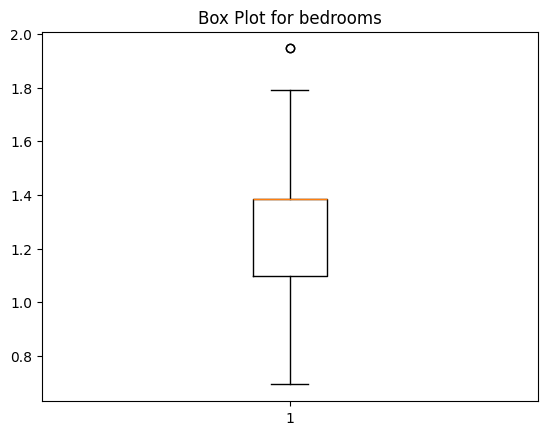

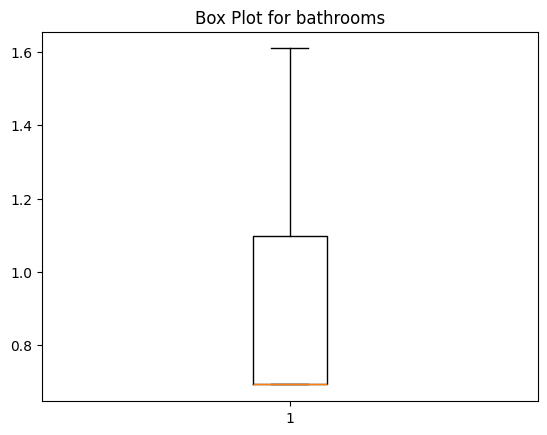

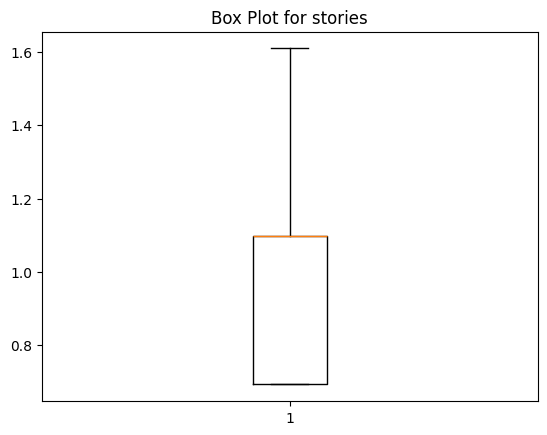

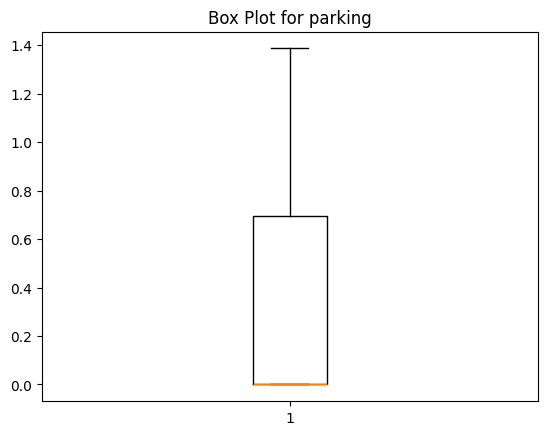

In [155]:
## Box plot to identify the outliers
for col in num_cols:
    plt.title(f"Box Plot for {col}")
    plt.boxplot(x=df[col])
    plt.show()

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.580085  0.387352   0.489741  0.395212  0.380967
area       0.580085  1.000000  0.156597   0.202441  0.070876  0.362641
bedrooms   0.387352  0.156597  1.000000   0.370372  0.470881  0.143906
bathrooms  0.489741  0.202441  0.370372   1.000000  0.323327  0.178392
stories    0.395212  0.070876  0.470881   0.323327  1.000000  0.035148
parking    0.380967  0.362641  0.143906   0.178392  0.035148  1.000000


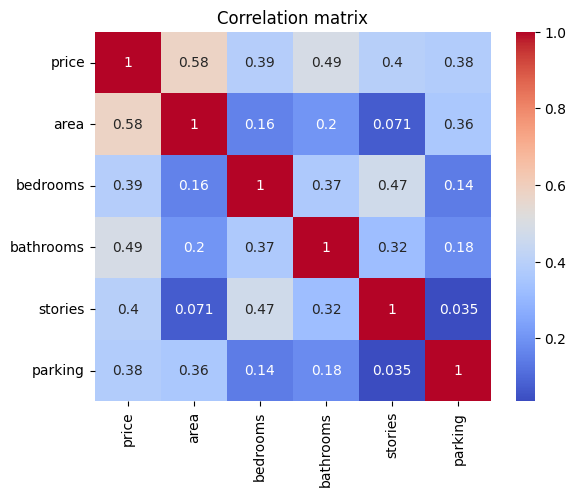

In [156]:
# correlation matrix and heatmap
corr = df[num_cols].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()



=== mainroad ===
mainroad
yes    468
no      77
Name: count, dtype: int64


/tmp/ipykernel_9334/908489076.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


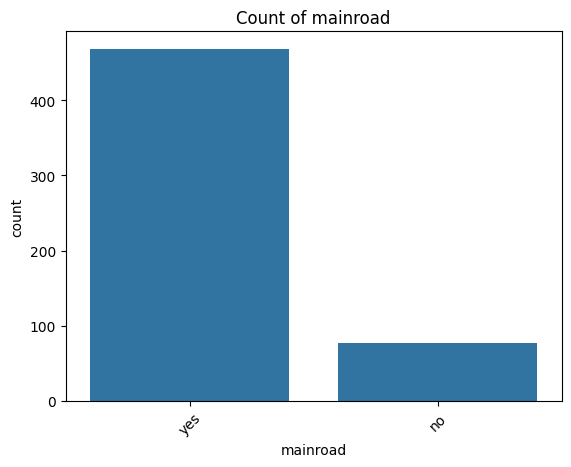


=== guestroom ===
guestroom
no     448
yes     97
Name: count, dtype: int64


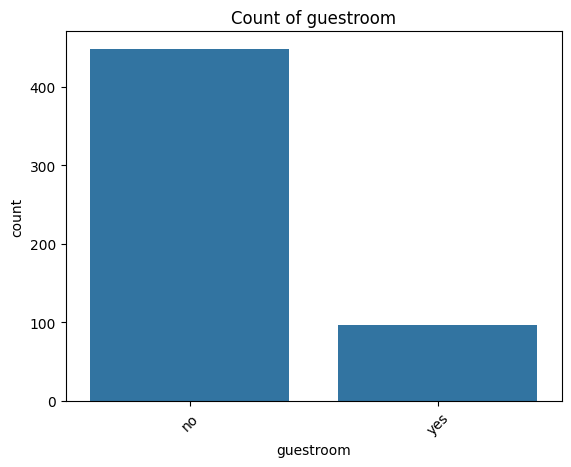


=== basement ===
basement
no     354
yes    191
Name: count, dtype: int64


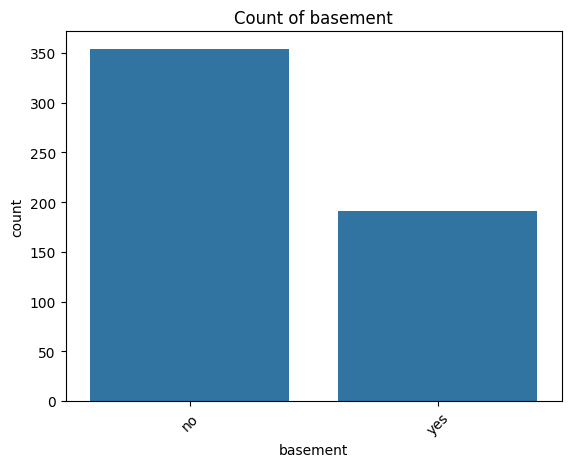


=== hotwaterheating ===
hotwaterheating
no     520
yes     25
Name: count, dtype: int64


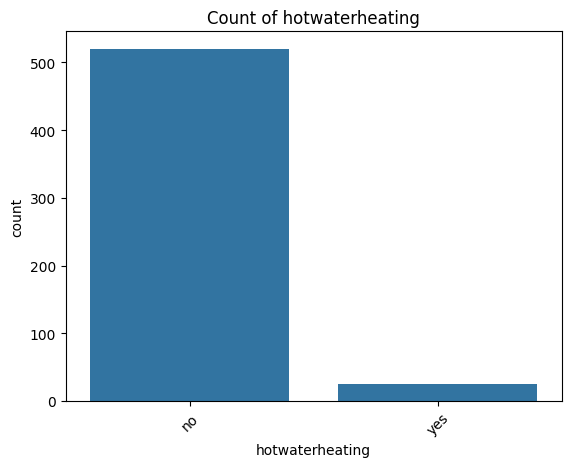


=== airconditioning ===
airconditioning
no     373
yes    172
Name: count, dtype: int64


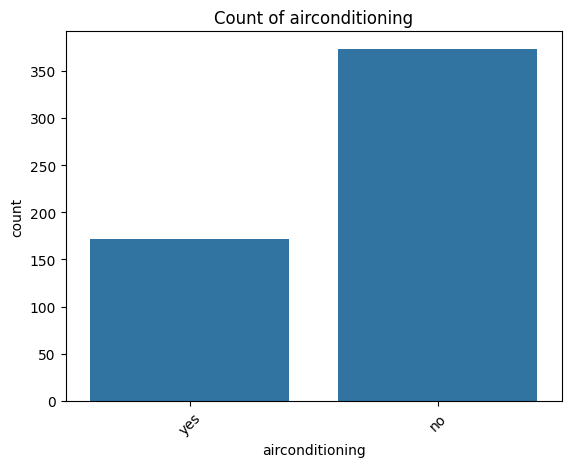


=== prefarea ===
prefarea
no     417
yes    128
Name: count, dtype: int64


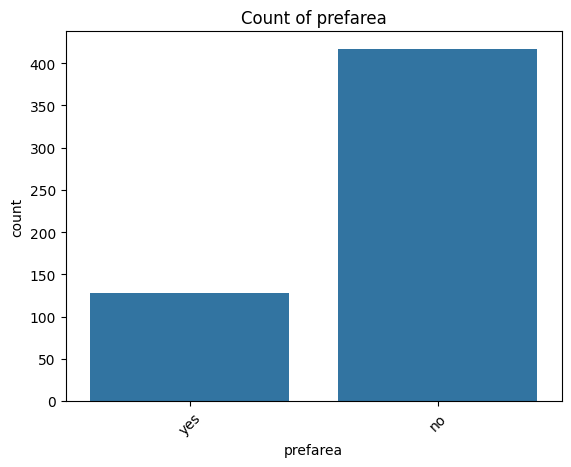


=== furnishingstatus ===
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


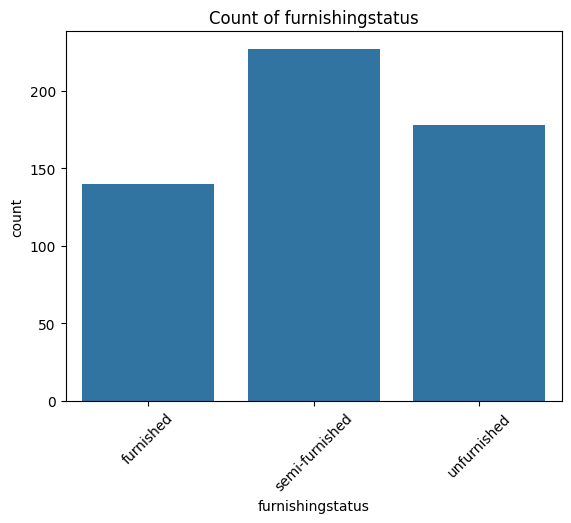

In [157]:
# 2. categorical features – value counts and countplots
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()


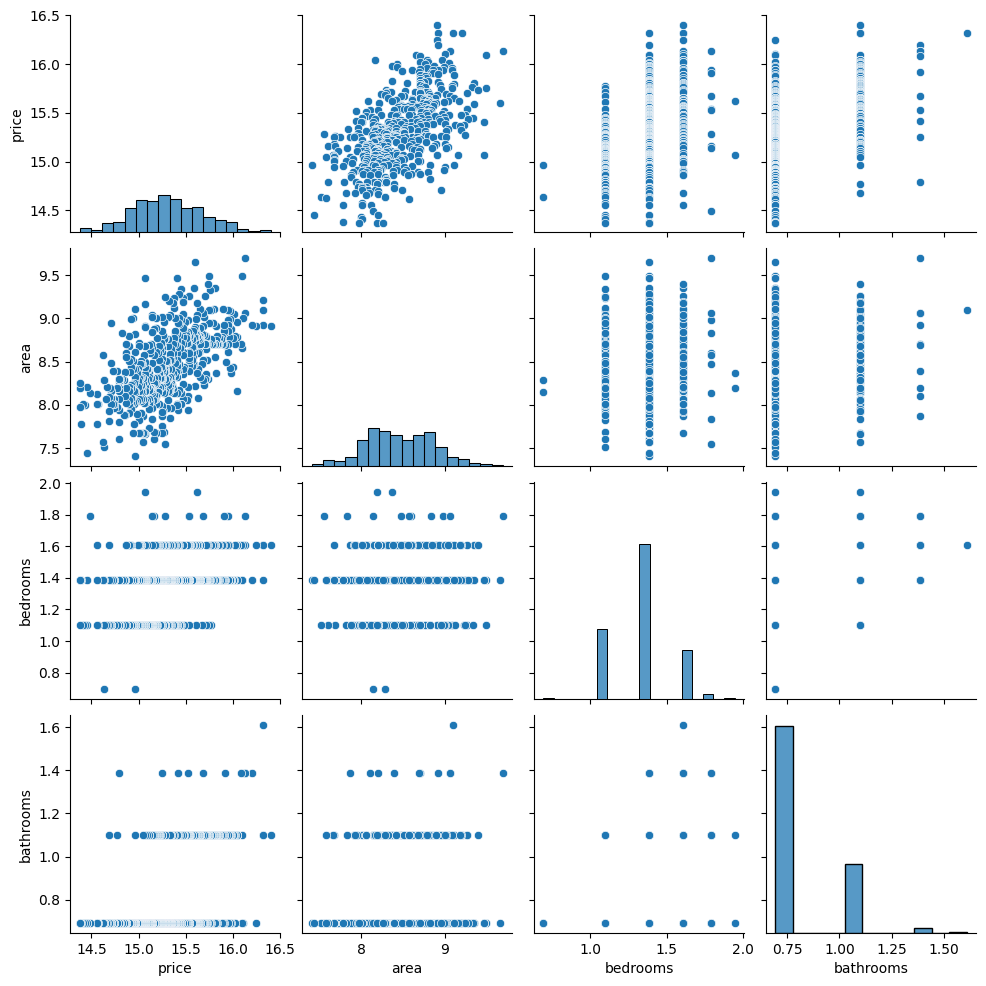

In [158]:
# pairwise relationships for a subset of variables
sns.pairplot(df[['price','area','bedrooms','bathrooms']])
plt.show()

*Preprocessing and feature engineering*

In [159]:

df_pre=df.copy()
df_pre.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,16.403275,8.912069,1.609438,1.098612,1.386294,yes,no,no,no,yes,1.098612,yes,furnished
1,16.321037,9.100637,1.609438,1.609438,1.609438,yes,no,no,no,yes,1.386294,no,furnished
2,16.321037,9.206433,1.386294,1.098612,1.098612,yes,no,yes,no,no,1.098612,yes,semi-furnished
3,16.318175,8.922792,1.609438,1.098612,1.098612,yes,no,yes,no,yes,1.386294,yes,furnished
4,16.250001,8.912069,1.609438,0.693147,1.098612,yes,yes,yes,no,yes,1.098612,no,furnished


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

scaler=StandardScaler()
one_encd=OneHotEncoder(drop='first',sparse_output=False)
encode_one=one_encd.fit_transform(df[cat_cols])
encoded_col_one=one_encd.get_feature_names_out(cat_cols)
encoded_df=pd.DataFrame(encode_one,columns=encoded_col_one,index=df.index)
df_ohe = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
df_ohe.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,16.403275,8.912069,1.609438,1.098612,1.386294,1.098612,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,16.321037,9.100637,1.609438,1.609438,1.609438,1.386294,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16.321037,9.206433,1.386294,1.098612,1.098612,1.098612,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,16.318175,8.922792,1.609438,1.098612,1.098612,1.386294,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,16.250001,8.912069,1.609438,0.693147,1.098612,1.098612,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [178]:
# numeric summaries and distributions
num_cols=df_ohe.select_dtypes(include=np.number).columns.tolist()


                                    price      area  bedrooms  bathrooms  \
price                            1.000000  0.580085  0.387352   0.489741   
area                             0.580085  1.000000  0.156597   0.202441   
bedrooms                         0.387352  0.156597  1.000000   0.370372   
bathrooms                        0.489741  0.202441  0.370372   1.000000   
stories                          0.395212  0.070876  0.470881   0.323327   
parking                          0.380967  0.362641  0.143906   0.178392   
mainroad_yes                     0.330041  0.331598 -0.002082   0.045215   
guestroom_yes                    0.277047  0.180186  0.087968   0.130472   
basement_yes                     0.218401  0.043309  0.107393   0.105734   
hotwaterheating_yes              0.088968 -0.013724  0.043087   0.068211   
airconditioning_yes              0.455159  0.262420  0.175671   0.194723   
prefarea_yes                     0.340557  0.219716  0.099041   0.069091   
furnishingst

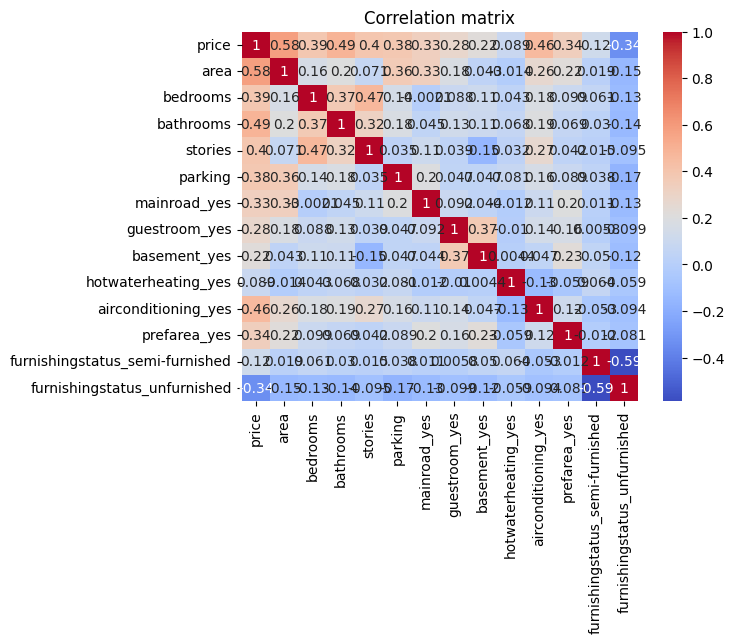

In [179]:
# correlation matrix and heatmap
corr=df_ohe[num_cols].corr()
print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()


In [161]:
df_ohe.to_csv("preprocessed_housing_data.csv",index=False)

In [162]:
X=df_ohe.drop(['price'],axis=1)
y=df_ohe['price']

In [163]:
X.shape

(545, 13)

In [164]:
y.shape

(545,)

**Do the spliting first then scaling to avoid data leakage**

In [165]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [166]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)


In [167]:
X_train.shape

(436, 13)

In [168]:
X_test.shape

(109, 13)